In [1]:
import numpy as np
# 수치/배열 처리를 위한 numpy

import matplotlib.pyplot as plt
# 점수 변화를 그래프로 그리기 위한 matplotlib

from sklearn.model_selection import train_test_split
# 훈련/테스트 데이터로 나누기 위한 함수

from sklearn.preprocessing import StandardScaler
# 스케일링(표준화) 도구

from sklearn.linear_model import SGDClassifier
# SGD(확률적 경사하강법) 기반 분류 모델

In [4]:
X = np.array([
    [80, 1, 0, 9],  # 아메리카노
    [75, 1, 0, 8],  # 아메리카노
    [70, 2, 0, 7],  # 아메리카노
    [65, 2, 1, 7],  # 아메리카노(약간 우유)

    [60, 3, 6, 6],  # 라떼
    [55, 4, 7, 5],  # 라떼
    [50, 3, 8, 4],  # 라떼
    [45, 4, 6, 4],  # 라떼

    [5,  9, 2, 0],  # 스무디
    [8,  8, 3, 0],  # 스무디
    [3, 10, 1, 0],  # 스무디
    [10, 7, 2, 0],  # 스무디
], dtype=float)

y = np.array([
    "Americano","Americano","Americano","Americano",
    "Latte","Latte","Latte","Latte",
    "Smoothie","Smoothie","Smoothie","Smoothie"
])


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

ss = StandardScaler()
train_scaled = ss.fit_transform(X_train)
test_scaled = ss.transform(X_test)


In [6]:
sc = SGDClassifier(loss="log_loss", random_state=42)
train_score = []
test_score = []
classes = np.unique(y_train)
for _ in range(300):
    sc.partial_fit(train_scaled, y_train, classes=classes)
    train_score.append(sc.score(train_scaled, y_train))
    test_score.append(sc.score(test_scaled, y_test))

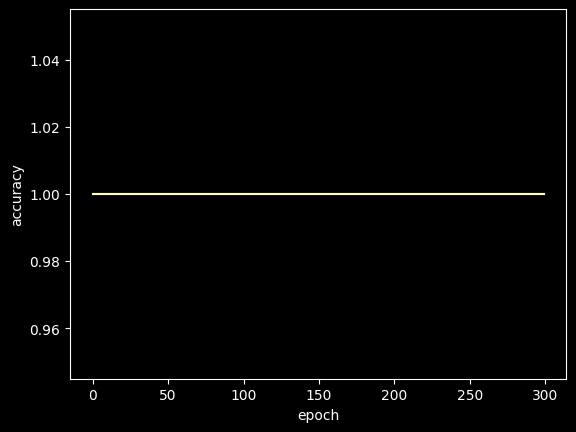

In [7]:
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.show()

In [8]:
best_epoch = 100
final_model = SGDClassifier(loss="log_loss", max_iter=best_epoch, tol=None, random_state=42)
final_model.fit(train_scaled, y_train)
print("train accuracy:", final_model.score(train_scaled, y_train))
print("test  accuracy:", final_model.score(test_scaled, y_test))

train accuracy: 1.0
test  accuracy: 1.0


In [9]:
sample = np.array([[8, 9, 2, 0]], dtype=float)
sample_scaled = ss.transform(sample)
pred = final_model.predict(sample_scaled)
proba = final_model.predict_proba(sample_scaled)
print("predict:", pred[0])
print("classes_:", final_model.classes_)
print("proba   :", np.round(proba, 3))

predict: Smoothie
classes_: ['Americano' 'Latte' 'Smoothie']
proba   : [[0. 0. 1.]]
